<a href="https://colab.research.google.com/github/sinchugowda887/Bank-Fraud-detection/blob/main/supply%20chain%20forecasting%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.3042
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2036
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1184
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0858
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0846
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0849
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0847
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0846
Epoch 9/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0838
Epoch 10/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0843
Epoch 11/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0836
Epoch 12/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0834
Epoch 13/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0833
Epoch 14/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0837
Epoch 15/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0846
Epoch 16/20
20/2

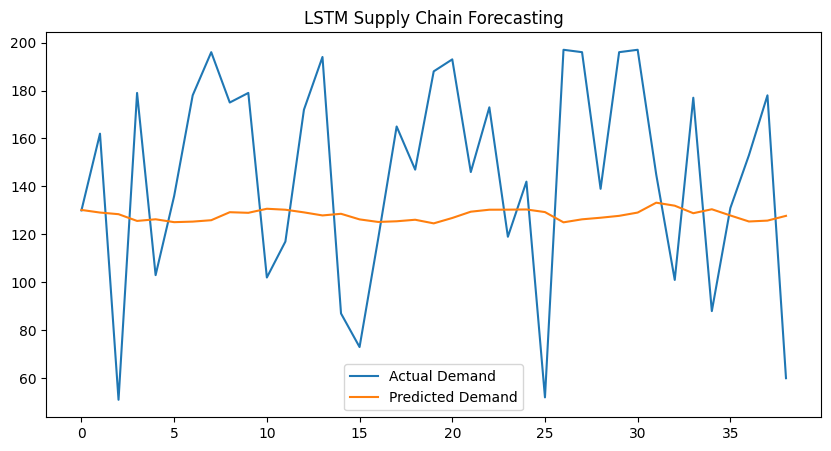

In [ ]:

# =========================
# IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# =========================
# CREATE DATA
# =========================
np.random.seed(42)
days = 200

data = pd.DataFrame({
    'Demand': np.random.randint(50, 200, size=days)
})

# =========================
# NORMALIZE DATA
# =========================
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# =========================
# CREATE SEQUENCES
# =========================
def create_sequences(data, time_steps=5):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

time_steps = 5
X, y = create_sequences(scaled_data, time_steps)

# =========================
# TRAIN TEST SPLIT
# =========================
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# =========================
# BUILD LSTM MODEL
# =========================
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(time_steps, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# =========================
# TRAIN MODEL
# =========================
model.fit(X_train, y_train, epochs=20, batch_size=8, verbose=1)

# =========================
# PREDICT
# =========================
y_pred = model.predict(X_test)

# Inverse transform
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)

# =========================
# PLOT
# =========================
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label="Actual Demand")
plt.plot(y_pred_inv, label="Predicted Demand")
plt.legend()
plt.title("LSTM Supply Chain Forecasting")
plt.show()